In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# Чтение данных
df = pd.read_csv('kvartiras.csv')

In [3]:
# Разделение колонки 'Балкон/Лолджия' на два признака
df['Есть Балкон'] = (df['Балкон/Лоджия (1, 2)'] == 1).astype(int)
df['Есть Лоджия'] = (df['Балкон/Лоджия (1, 2)'] == 2).astype(int)
df.drop('Балкон/Лоджия (1, 2)', axis=1, inplace=True)

In [4]:
#One-Hot encoding для станций метро

metro_dummies = pd.get_dummies(df['Ближайшая станция метро'], prefix='Metro', drop_first=True)
df = pd.concat([df, metro_dummies], axis=1)
df.drop('Ближайшая станция метро', axis=1, inplace=True)

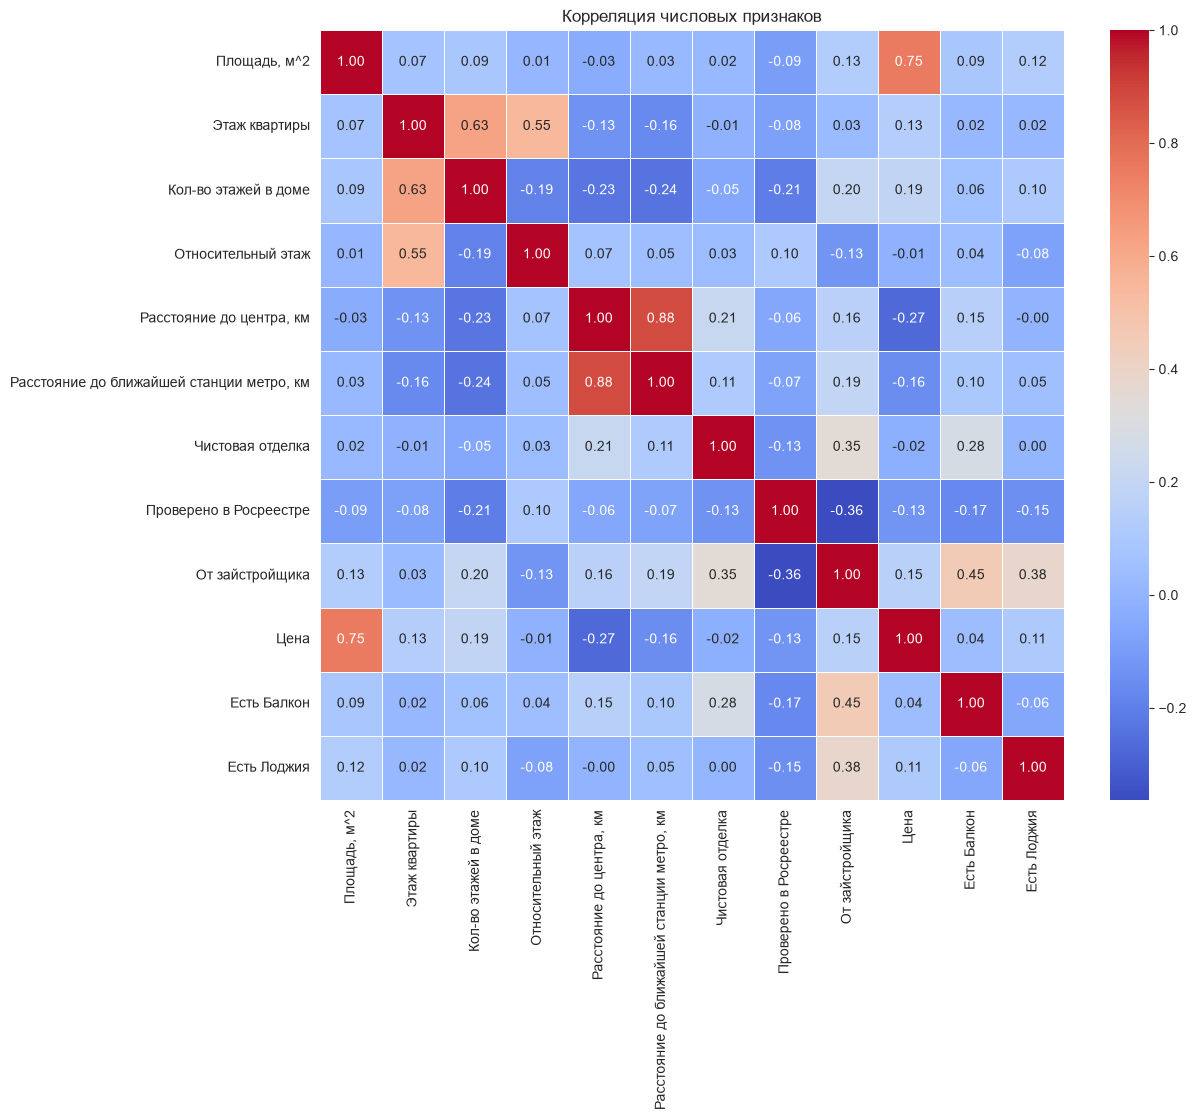

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция числовых признаков')
plt.show()

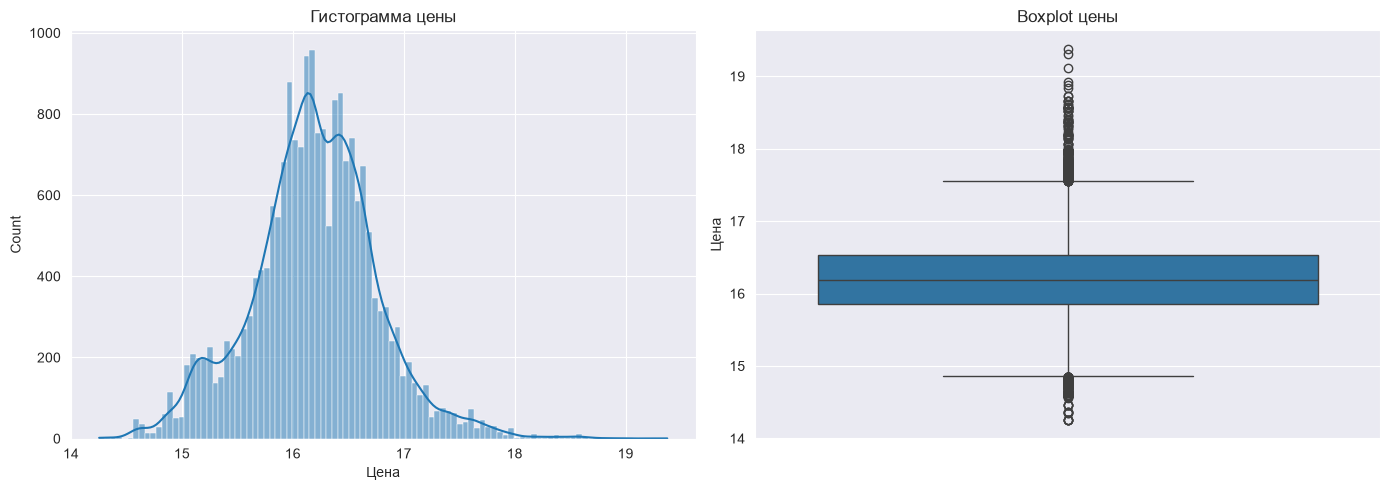

In [6]:
# Визуализация распределения цен

y_log = np.log1p(df['Цена'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y_log, bins=100, kde=True, ax=axes[0])
axes[0].set_title('Гистограмма цены')
sns.boxplot(y_log, ax=axes[1])
axes[1].set_title('Boxplot цены')
plt.tight_layout()
plt.show()

На втором графике есть подозрительные выбросы, их нужно исследовать

Скос цены: 5.84
Скос log(цены): 0.13


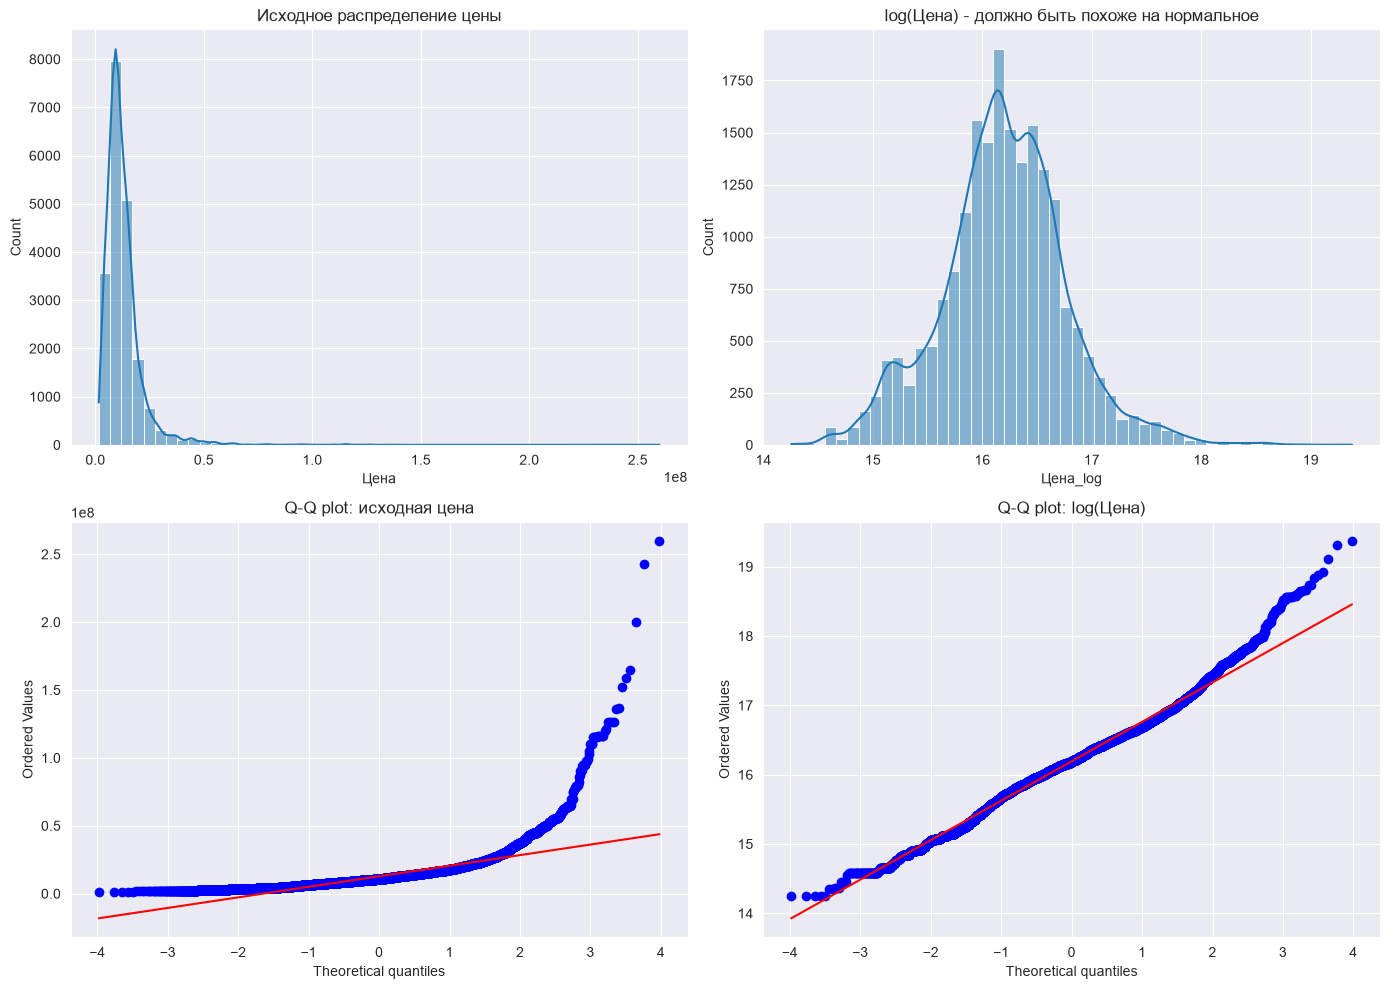

In [7]:
# Проверяем скошенность
print(f"Скос цены: {df['Цена'].skew():.2f}")  # Должен быть > 1

# Логарифмируем
df['Цена_log'] = np.log1p(df['Цена'])
print(f"Скос log(цены): {df['Цена_log'].skew():.2f}")  # Должен стать ~0

# Смотрим результат
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Цена'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Исходное распределение цены')

sns.histplot(df['Цена_log'], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title('log(Цена) - должно быть похоже на нормальное')

# Q-Q plots для проверки нормальности
from scipy import stats
stats.probplot(df['Цена'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q plot: исходная цена')
stats.probplot(df['Цена_log'], dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q plot: log(Цена)')

plt.tight_layout()
plt.show()

скос близок к 0, поэтому все нормально

In [8]:
# ВАЖНО: МОДЕЛЬ БУДЕТ ПРЕДСКАЗЫВАТЬ ЛОГАРИФМИРОВАННУЮ ЦЕНУ, ЧТОБЫ ВЫВОДИТЬ ЧИТАБЕЛЬНЫЙ ОТВЕТ, НУЖНО ПРИМЕНЯТЬ np.expm1() 🙂🙂🙂

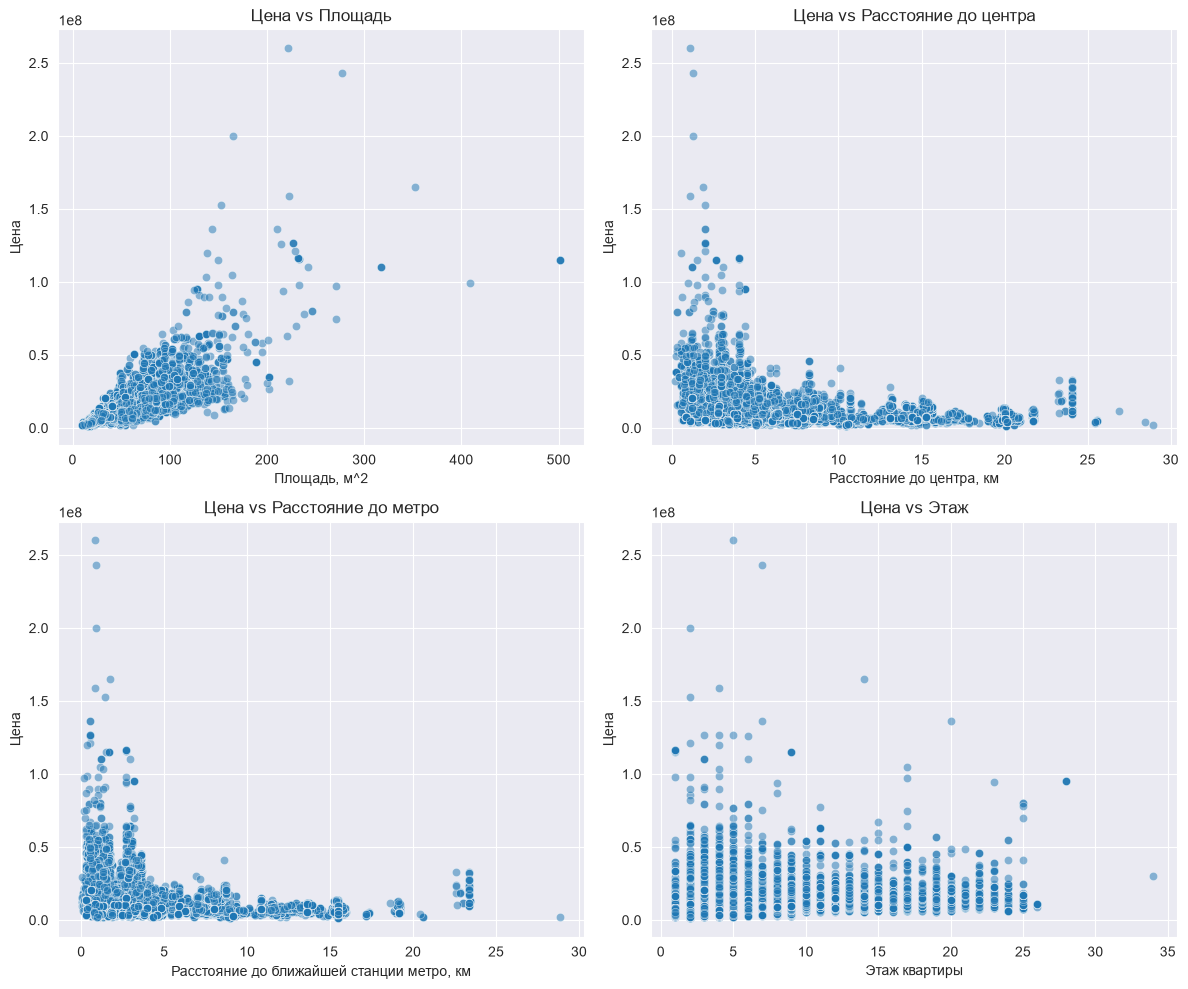

In [9]:
# Графики ключевых факторов против цены

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=df, x='Площадь, м^2', y='Цена', ax=axes[0,0], alpha=0.5)
axes[0,0].set_title('Цена vs Площадь')
sns.scatterplot(data=df, x='Расстояние до центра, км', y='Цена', ax=axes[0,1], alpha=0.5)
axes[0,1].set_title('Цена vs Расстояние до центра')
sns.scatterplot(data=df, x='Расстояние до ближайшей станции метро, км', y='Цена', ax=axes[1,0], alpha=0.5)
axes[1,0].set_title('Цена vs Расстояние до метро')
sns.scatterplot(data=df, x='Этаж квартиры', y='Цена', ax=axes[1,1], alpha=0.5)
axes[1,1].set_title('Цена vs Этаж')
plt.tight_layout()
plt.show()

In [10]:
# 1. Удаляем ненужные столбцы
df = df.drop(columns=['Цена', 'Относительный этаж', 'Расстояние до ближайшей станции метро, км'])

# 2. Булевы столбцы метро превращаем в int (0/1)
metro_cols = [col for col in df.columns if col.startswith('Metro_')]
df[metro_cols] = df[metro_cols].astype(int)

In [11]:
room_mapping = {
    'студия': 0.5,  # логически между 0 и 1
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4
}
df['Кол-во комнат'] = df['Кол-во комнат'].replace(room_mapping).astype(float)

In [12]:
# Косметика

desired_order = [
    'Кол-во комнат',
    'Площадь, м^2',
    'Этаж квартиры',
    'Кол-во этажей в доме',
    'Расстояние до центра, км',
    'Чистовая отделка',
    'Проверено в Росреестре',
    'От зайстройщика',
    'Есть Балкон',
    'Есть Лоджия',
    'Metro_Аметьево',
    'Metro_Горки',
    'Metro_Дубравная',
    'Metro_Козья слобода',
    'Metro_Кремлёвская',
    'Metro_Площадь Тукая',
    'Metro_Проспект Победы',
    'Metro_Северный вокзал',
    'Metro_Суконная слобода',
    'Metro_Яшьлек',
    'Цена_log'
]

final_order = [col for col in desired_order if col in df.columns]
df = df[final_order]

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20100 entries, 0 to 20099
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Кол-во комнат             20100 non-null  float64
 1   Площадь, м^2              20100 non-null  float64
 2   Этаж квартиры             20100 non-null  int64  
 3   Кол-во этажей в доме      20100 non-null  int64  
 4   Расстояние до центра, км  20100 non-null  float64
 5   Чистовая отделка          20100 non-null  int64  
 6   Проверено в Росреестре    20100 non-null  int64  
 7   От зайстройщика           20100 non-null  int64  
 8   Есть Балкон               20100 non-null  int64  
 9   Есть Лоджия               20100 non-null  int64  
 10  Metro_Аметьево            20100 non-null  int64  
 11  Metro_Горки               20100 non-null  int64  
 12  Metro_Дубравная           20100 non-null  int64  
 13  Metro_Козья слобода       20100 non-null  int64  
 14  Metro_Кремлёвская

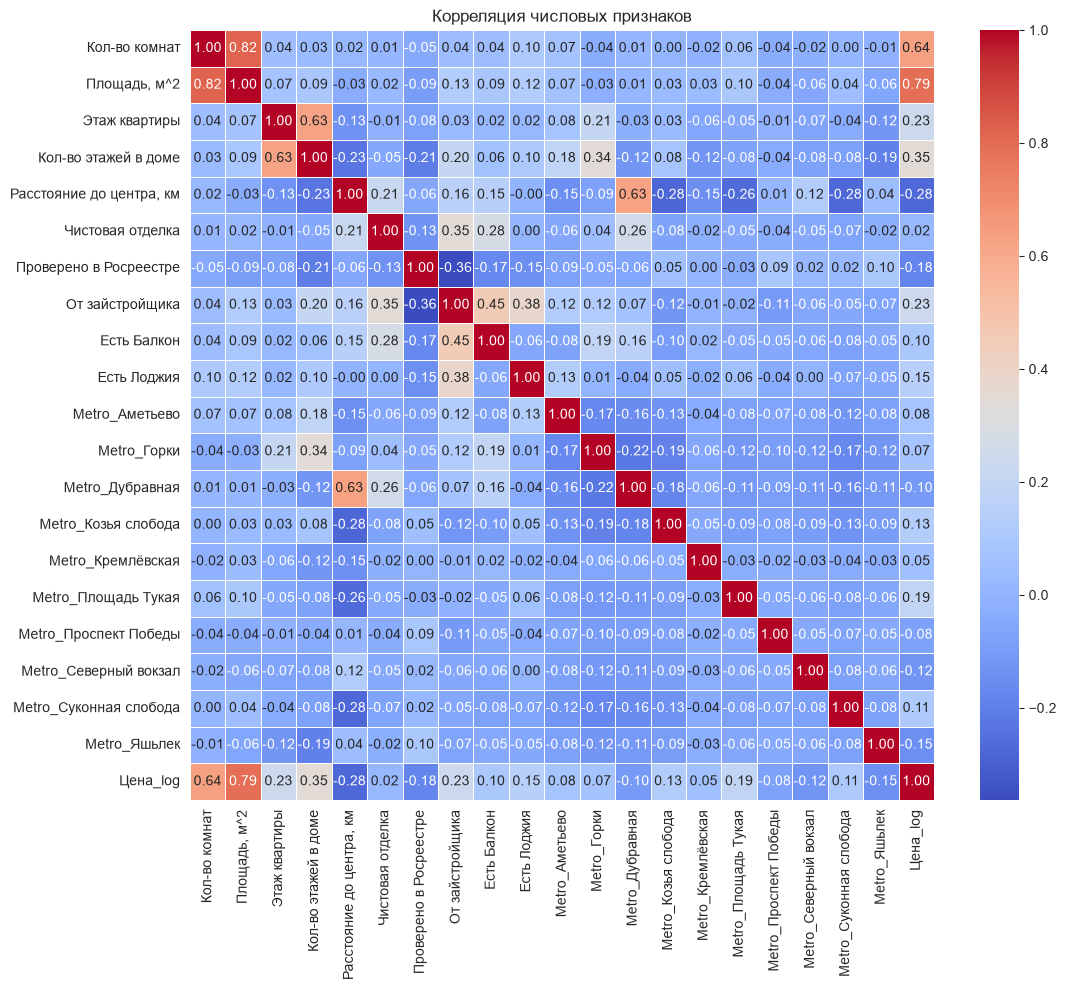

In [14]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция числовых признаков')
plt.show()

In [15]:
#заметна корреляция между площадью и количеством комнат, нужно исправить.

df.drop('Кол-во комнат', axis=1, inplace=True)

In [16]:
df.to_csv('dataset_prepared.csv', index=False)

In [17]:
# Берём случайные 1000 квартир
df_sample_1k = df.sample(n=1000, random_state=42)
df_sample_3k = df.sample(n=3000, random_state=67)
df_sample_5k = df.sample(n=5000, random_state=68)
df_sample_10k = df.sample(n=10000, random_state=43)

# Сохраняем отдельно
df_sample_1k.to_csv('dataset_sample_1000.csv', index=False)
df_sample_3k.to_csv('dataset_sample_3000.csv', index=False)
df_sample_5k.to_csv('dataset_sample_5000.csv', index=False)
df_sample_10k.to_csv('dataset_sample_10000.csv', index=False)


# print(f"Размер сэмпла: {df_sample.shape}")